# Week 6 Student Worksheet: Spatial Prediction Shootout

## Traditional Stats vs. Machine Learning: Filling the Gaps

> *"Kriging tells you where it's uncertain. ML just says 'trust me.'"*

### Today's Mission

Transform Week 5's discrete rainfall stations into **continuous rainfall surfaces** using **two fundamentally different approaches**:

1. **Kriging (Statistical)** — uses spatial correlation + provides uncertainty
2. **Random Forest (ML)** — uses data patterns + easily adds features

Then compare them head-to-head with two simpler methods (Nearest Neighbor, IDW) and determine which gives the Commander more actionable intelligence.

> Fill in the code cells marked with `# YOUR CODE HERE`. Use AI tools strategically — but understand every line you write.

In [1]:
# Install required packages (run once)
%pip install pykrige scikit-learn rasterio rasterstats --quiet

Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.


---

## Cell [1]: Environment Setup & Data Loading (Slide 2)

Load the Fung-wong typhoon data and filter to the study area. Reuse your Week 5 `parse_rainfall_json()` function.

**AI Prompt Suggestion**:
```
I need to load fungwong_202511.json and parse it into a GeoDataFrame using
my Week 5 parse_rainfall_json() function. Then filter to 花蓮縣 and 宜蘭縣,
remove -998/zero rain stations, and convert to EPSG:3826.
Show me the top 5 stations by rain_1hr.
```

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
import os, pathlib
from shapely.geometry import Point
warnings.filterwarnings('ignore')

# Find project root dynamically
_here = pathlib.Path('.').resolve()
PROJECT_ROOT = None
for _p in [_here] + list(_here.parents):
    if (_p / 'data' / 'scenarios').exists():
        PROJECT_ROOT = _p
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = pathlib.Path(r'D:\YongZhi\2026_RS')
DATA_DIR = PROJECT_ROOT / 'data'

# 1. Define normalize_cwa_json() and parse_rainfall_json() (from Week 5)
def normalize_cwa_json(raw):
    """Detect JSON format and return the station list."""
    if 'records' in raw and 'Station' in raw['records']:
        return raw['records']['Station']
    if 'cwaopendata' in raw and 'dataset' in raw['cwaopendata']:
        if 'Station' in raw['cwaopendata']['dataset']:
            return raw['cwaopendata']['dataset']['Station']
    return []

def parse_rainfall_json(data):
    """Parse station JSON into a GeoDataFrame with CRS EPSG:4326."""
    stations = normalize_cwa_json(data)
    parsed_list = []
    for st in stations:
        try:
            name = st['StationName']
            sid  = st['StationId']
            coords = st.get('GeoInfo', {}).get('Coordinates', [])
            lat, lon = None, None
            if len(coords) >= 2:
                for c in coords:
                    if c.get('CoordinateName') == 'WGS84':
                        lat = float(c['StationLatitude'])
                        lon = float(c['StationLongitude'])
                        break
            elif len(coords) == 1:
                lat = float(coords[0]['StationLatitude'])
                lon = float(coords[0]['StationLongitude'])
            rain_elem = st.get('RainfallElement', {})
            if 'Now' in rain_elem:
                rain_1hr = float(rain_elem['Now']['Precipitation'])
            elif 'Past1hr' in rain_elem:
                rain_1hr = float(rain_elem['Past1hr']['Precipitation'])
            else:
                rain_1hr = 0.0
            rain_3hr  = float(rain_elem.get('Past3hr',  {}).get('Precipitation', 0))
            rain_24hr = float(rain_elem.get('Past24hr', {}).get('Precipitation', 0))
            if rain_1hr  == -998: rain_1hr  = 0
            if rain_3hr  == -998: rain_3hr  = 0
            if rain_24hr == -998: rain_24hr = 0
            county = st.get('GeoInfo', {}).get('CountyName', '')
            town   = st.get('GeoInfo', {}).get('TownName', '')
            if lat is not None and lon is not None:
                parsed_list.append({
                    'station_name': name, 'station_id': sid,
                    'county': county, 'town': town,
                    'lat': lat, 'lon': lon,
                    'rain_1hr': rain_1hr, 'rain_3hr': rain_3hr, 'rain_24hr': rain_24hr,
                })
        except Exception:
            continue
    df = pd.DataFrame(parsed_list)
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['lon'], df['lat']), crs="EPSG:4326")
    return gdf

# 2. Load JSON
with open(DATA_DIR / 'scenarios' / 'fungwong_202511.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# 3. Parse into GeoDataFrame
gdf_rain = parse_rainfall_json(data)

# 4. Filter to Hualien + Yilan
study_rain = gdf_rain[gdf_rain['county'].isin(['花蓮縣', '宜蘭縣'])].copy()

# 5. Remove stations with rain_1hr <= 0
study_rain = study_rain[study_rain['rain_1hr'] > 0].copy()

# 6. Convert to EPSG:3826
study_rain_3826 = study_rain.to_crs(epsg=3826)

# Extract coordinate arrays for Kriging / ML
x = study_rain_3826.geometry.x.values  # Easting (meters)
y = study_rain_3826.geometry.y.values  # Northing (meters)
z = study_rain_3826['rain_1hr'].values

print(f"Study area stations (rain > 0): {len(study_rain_3826)}")
print(f"CRS: {study_rain_3826.crs}")
print(f"\nTop 5 stations:")
print(study_rain_3826.nlargest(5, 'rain_1hr')[['station_name', 'county', 'rain_1hr']].to_string(index=False))

Study area stations (rain > 0): 89
CRS: EPSG:3826

Top 5 stations:
station_name county  rain_1hr
          蘇澳    宜蘭縣     130.5
     國五S047K    宜蘭縣      80.5
          五結    宜蘭縣      71.0
          冬山    宜蘭縣      61.5
     國五S041K    宜蘭縣      46.0


---

## Cell [2a]: Variogram — First Attempt (Naive)

Try running Kriging directly on the raw rainfall data. **Don't worry if it looks bad — that's the point.**

**Key Concepts** (will make sense after you see the result):
- **Nugget**: How noisy is each measurement?
- **Sill**: What's the maximum difference between stations?
- **Range**: How far apart do stations need to be before they stop "knowing about each other"?

**CRS Warning**: The x, y arrays MUST be in EPSG:3826 (meters). Using lat/lon will give wrong results.

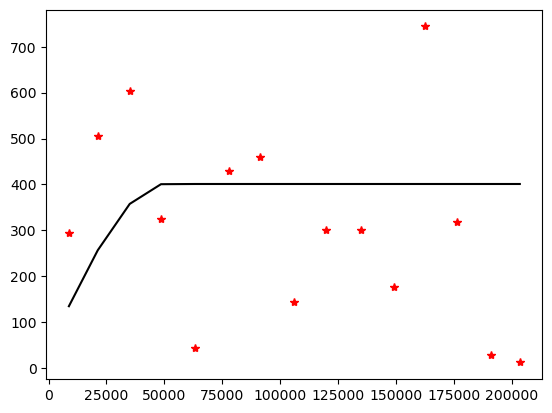

Sill:   360.8
Range:  50000 m (50.0 km)
Nugget: 40.1

⚠️ Look at the plot — do the dots follow the curve?


In [3]:
from pykrige.ok import OrdinaryKriging

# First attempt: run Kriging on raw rainfall data
initial_sill   = float(z.var())
initial_range  = 50000.0
initial_nugget = float(z.var() * 0.1)

OK_naive = OrdinaryKriging(x, y, z, variogram_model='spherical',
                            verbose=False, enable_plotting=True, nlags=15,
                            variogram_parameters={'sill': initial_sill,
                                                  'range': initial_range,
                                                  'nugget': initial_nugget})

params = OK_naive.variogram_model_parameters
print(f"Sill:   {params[0]:.1f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.1f}")
print("\n⚠️ Look at the plot — do the dots follow the curve?")

## Cell [2b]: Why Did It Fail? — Look at the Histogram

The variogram looked bad. Before blaming the tool, **look at your data**.

Plot a histogram of the rainfall values. What do you see?

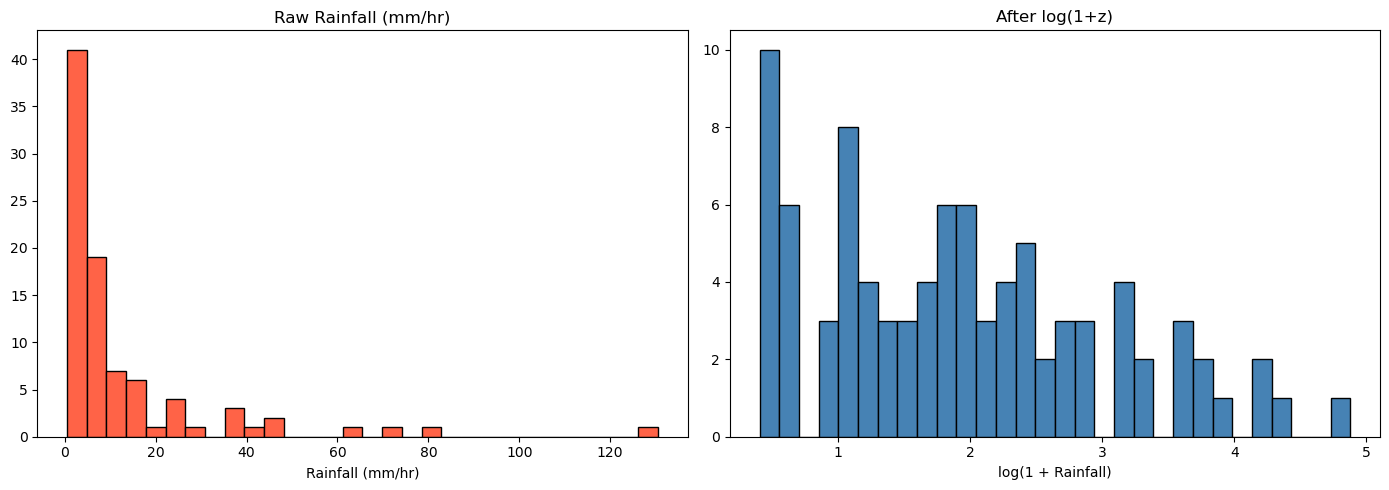

Left: most stations < 10 mm, but a few are 50-130 mm.
Those extreme values mess up the variogram.
Right: after log-transform, the values are more balanced.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(z, bins=30, color='tomato', edgecolor='black')
axes[0].set_title('Raw Rainfall (mm/hr)')
axes[0].set_xlabel('Rainfall (mm/hr)')

z_log = np.log1p(z)
axes[1].hist(z_log, bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('After log(1+z)')
axes[1].set_xlabel('log(1 + Rainfall)')
plt.tight_layout()
plt.show()

print("Left: most stations < 10 mm, but a few are 50-130 mm.")
print("Those extreme values mess up the variogram.")
print("Right: after log-transform, the values are more balanced.")

## Cell [2c]: Variogram — Second Attempt (with Log-Transform)

Now redo the variogram using the log-transformed data. Compare this plot with Cell [2a] — it should be much better.

**Rule of thumb**: If your histogram has a long tail to the right, apply `np.log1p(z)` before Kriging, then use `np.expm1()` to convert back after prediction.

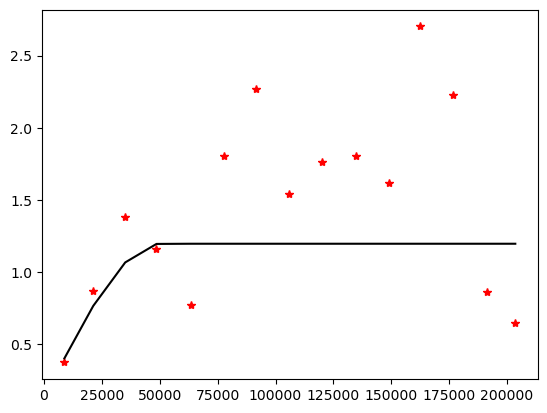

Sill:   1.076
Range:  50000 m (50.0 km)
Nugget: 0.120

✅ Compare with Cell [2a] — the dots should follow the curve now.


In [5]:
z_log = np.log1p(z)
initial_sill   = float(z_log.var())
initial_range  = 50000.0
initial_nugget = float(z_log.var() * 0.1)

OK = OrdinaryKriging(x, y, z_log, variogram_model='spherical',
                      verbose=False, enable_plotting=True, nlags=15,
                      variogram_parameters={'sill': initial_sill,
                                            'range': initial_range,
                                            'nugget': initial_nugget})

params = OK.variogram_model_parameters
print(f"Sill:   {params[0]:.3f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.3f}")
print("\n✅ Compare with Cell [2a] — the dots should follow the curve now.")

## Cell [2d]: Which Variogram Fits Best? — Range & Model Comparison (Slide 7)

Compare variograms **one variable at a time** — this is how scientists isolate effects:

- **Figure 1**: Fix model = **Spherical**, vary Range (50km, 25km, 15km) → what does Range do?
- **Figure 2**: Fix model = **Exponential**, vary Range (50km, 25km, 15km) → same exercise
- **Then compare**: same Range, different model → what does the model choice do?

**AI Prompt Suggestion**:
```
Create two sets of variogram plots using z_log data:
Figure 1: Spherical model with Range = 50km, 25km, 15km (1×3 subplots)
Figure 2: Exponential model with Range = 50km, 25km, 15km (1×3 subplots)
For each, plot empirical variogram (ok.lags vs ok.semivariance) as red dots
and the fitted model curve as a black line.
Compute SSE for each config and print a summary table.
Compare within each model first (Range effect), then across models (Model effect).
```

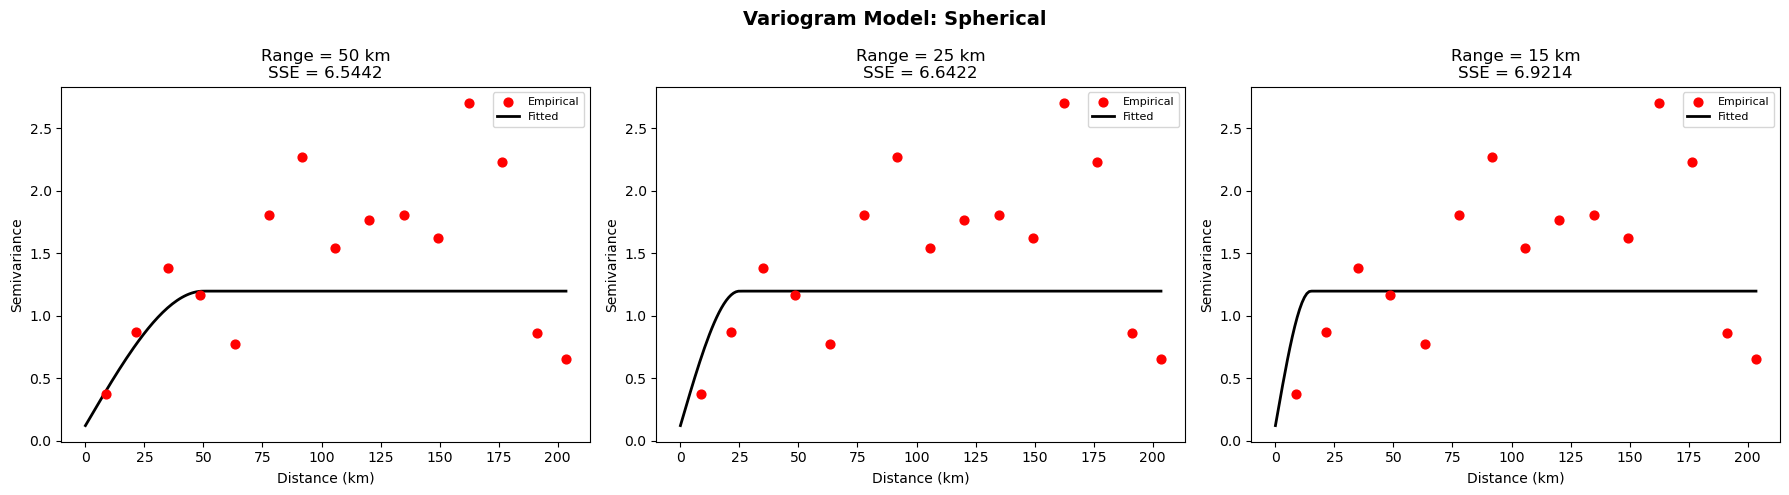

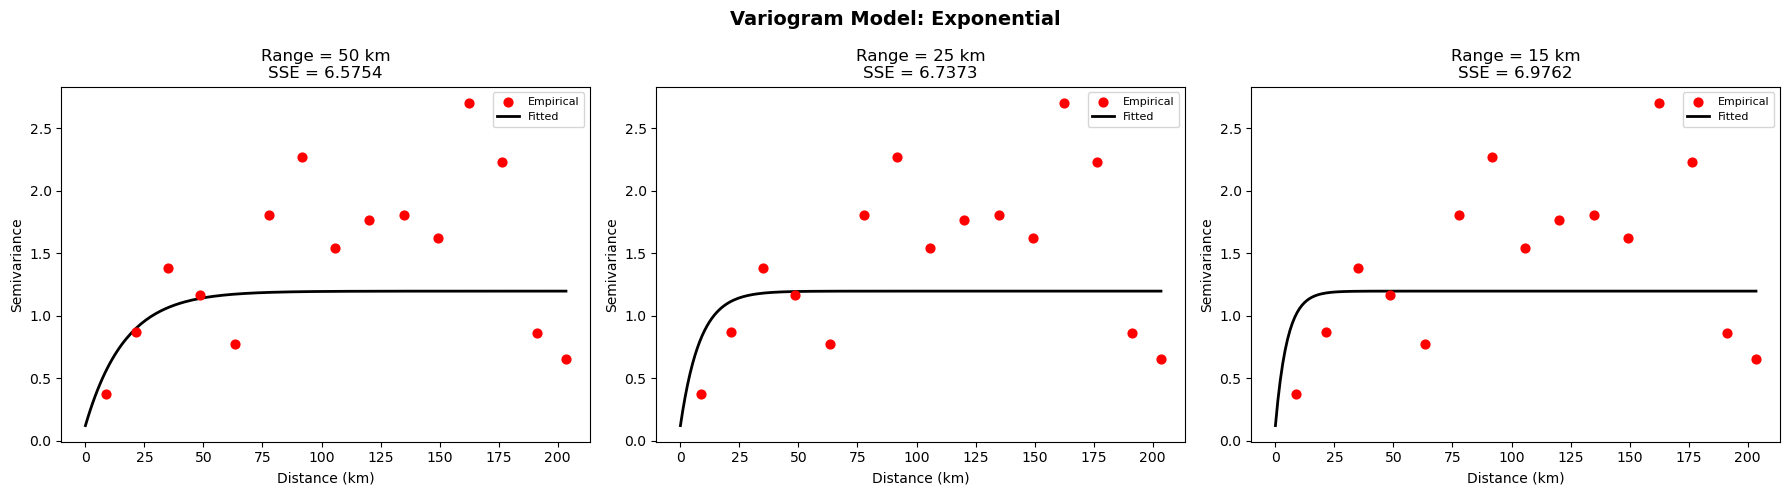


📊 Summary Table:
      Model  Range_km      SSE
  spherical        50 6.544171
  spherical        25 6.642205
  spherical        15 6.921389
exponential        50 6.575366
exponential        25 6.737273
exponential        15 6.976205

💡 Best fit: spherical with Range = 50 km (SSE = 6.5442)


In [6]:
ranges_km = [50, 25, 15]
models_list = ['spherical', 'exponential']
results = []

for model_name in models_list:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Variogram Model: {model_name.capitalize()}', fontsize=14, fontweight='bold')
    for ax, rkm in zip(axes, ranges_km):
        sill_val   = float(z_log.var())
        nugget_val = float(z_log.var() * 0.1)
        ok_test = OrdinaryKriging(x, y, z_log, variogram_model=model_name,
                                   verbose=False, enable_plotting=False, nlags=15,
                                   variogram_parameters={'sill': sill_val,
                                                         'range': rkm * 1000,
                                                         'nugget': nugget_val})
        # Empirical variogram (red dots)
        ax.scatter(ok_test.lags / 1000, ok_test.semivariance, c='red', s=40, zorder=5, label='Empirical')
        # Fitted model curve (black line)
        lag_range = np.linspace(0, ok_test.lags.max(), 200)
        fitted = ok_test.variogram_function(ok_test.variogram_model_parameters, lag_range)
        ax.plot(lag_range / 1000, fitted, 'k-', lw=2, label='Fitted')
        # SSE
        fitted_at_lags = ok_test.variogram_function(ok_test.variogram_model_parameters, ok_test.lags)
        sse = np.sum((ok_test.semivariance - fitted_at_lags) ** 2)
        ax.set_title(f'Range = {rkm} km\nSSE = {sse:.4f}')
        ax.set_xlabel('Distance (km)')
        ax.set_ylabel('Semivariance')
        ax.legend(fontsize=8)
        results.append({'Model': model_name, 'Range_km': rkm, 'SSE': sse})
    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results)
print("\n📊 Summary Table:")
print(df_results.to_string(index=False))
best = df_results.loc[df_results['SSE'].idxmin()]
print(f"\n💡 Best fit: {best['Model']} with Range = {int(best['Range_km'])} km (SSE = {best['SSE']:.4f})")

## Cell [3]: Define the Interpolation Grid & Run Kriging (Slide 8)

Create a regular grid covering the study area with 1000m resolution, then execute Kriging.

**Think about**:
- What units is the grid in? (Hint: same as your CRS = meters)
- Why add a buffer around the station extent?

**Important**: Kriging runs in log-space. After prediction, **back-transform** with `np.expm1()` to get rainfall in mm/hr.

In [7]:
import time

buffer_m   = 5000
resolution = 1000  # meters

x_min = x.min() - buffer_m
x_max = x.max() + buffer_m
y_min = y.min() - buffer_m
y_max = y.max() + buffer_m
grid_x = np.arange(x_min, x_max, resolution)
grid_y = np.arange(y_min, y_max, resolution)

print(f"Grid: {len(grid_x)}×{len(grid_y)} = {len(grid_x)*len(grid_y):,} points @ {resolution}m")

t0 = time.time()
z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
print(f"✓ Kriging (log-space) done in {time.time()-t0:.1f}s")

# Back-transform to real rainfall (mm/hr)
z_kriging = np.expm1(z_kriging_log)
z_kriging[z_kriging < 0] = 0
ss_kriging = ss_kriging_log  # keep log-space variance for Sigma Map

print(f"  z range (mm/hr): {np.nanmin(z_kriging):.1f} - {np.nanmax(z_kriging):.1f}")

Grid: 87×211 = 18,357 points @ 1000m
✓ Kriging (log-space) done in 0.1s
  z range (mm/hr): 0.5 - 71.2


---

## Cell [4]: Machine Learning — Random Forest Prediction (Slide 9)

**Captain's Log**: Treating coordinates as input features. ML learns `f(easting, northing) → rainfall`. Simple, but no uncertainty map.

**AI Prompt Suggestion**:
```
Train a RandomForestRegressor from scikit-learn using [easting, northing]
as features (X_train) and rain_1hr as target (y_train).
Use n_estimators=200, min_samples_leaf=3, random_state=42.
Then predict on the same grid as Kriging.
```

In [8]:
from sklearn.ensemble import RandomForestRegressor

X_train = np.column_stack([x, y])
y_train = z

rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)
rf.fit(X_train, y_train)
print(f"RF Training R²: {rf.score(X_train, y_train):.3f}")

grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
X_grid = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

t0 = time.time()
z_rf = rf.predict(X_grid).reshape(grid_xx.shape)
print(f"✓ Random Forest done in {time.time()-t0:.1f}s")
print(f"  z range: {z_rf.min():.1f} - {z_rf.max():.1f} mm/hr")

RF Training R²: 0.775
✓ Random Forest done in 0.0s
  z range: 0.6 - 62.6 mm/hr


## Cell [5]: ML Glass Box — Feature Importance (Slide 11)

**Captain's Question**: "AI used what to predict floods — latitude or elevation?"

Even though ML is a "black box", we can peek inside with `.feature_importances_`.

In [9]:
importances = rf.feature_importances_
print("Feature Importance:")
print(f"  Easting (X):  {importances[0]:.3f}")
print(f"  Northing (Y): {importances[1]:.3f}")
print(f"\nThe model relies mostly on {'easting' if importances[0] > importances[1] else 'northing'}.")
print("Think: does this make physical sense for Typhoon Fung-wong?")

Feature Importance:
  Easting (X):  0.485
  Northing (Y): 0.515

The model relies mostly on northing.
Think: does this make physical sense for Typhoon Fung-wong?


---

## ⏸️ Lab 1: The Four-Way Interpolation Shootout (40 min)

### Cell [6]: Nearest Neighbor + IDW

Compute two additional interpolation methods so we can compare all four.

**AI Prompt Suggestion**:
```
Use scipy.interpolate.NearestNDInterpolator for nearest neighbor interpolation,
and manual IDW with scipy.spatial.distance.cdist (power=2) for IDW.
Both should predict on the same meshgrid as Kriging and RF.
Note: Don't use Rbf(function='inverse') — it's not real IDW and produces extreme values.
```

In [10]:
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

# Nearest Neighbor
nn_interp = NearestNDInterpolator(list(zip(x, y)), z)
z_nn = nn_interp(grid_xx, grid_yy)

# IDW (manual, power=2)
pts      = np.column_stack([x, y])
grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
dists = cdist(grid_pts, pts)
dists[dists < 1] = 1  # avoid division by zero
power   = 2
weights = 1.0 / (dists ** power)
z_idw   = ((weights @ z) / weights.sum(axis=1)).reshape(grid_xx.shape)

print("✓ Nearest Neighbor + IDW computed")

✓ Nearest Neighbor + IDW computed


### Cell [7]: Four Methods Side by Side (Slide 13)

Create a 2×2 figure comparing all four interpolation methods.

**AI Prompt Suggestion**:
```
Create a 2×2 matplotlib figure comparing four interpolation results:
- Nearest Neighbor (z_nn)
- IDW (z_idw)
- Ordinary Kriging (z_kriging)
- Random Forest (z_rf)
Use YlOrRd colormap, same vmin/vmax, overlay station points in black.
Add descriptive subtitles (e.g., "Voronoi Patchwork", "Bullseye Effect",
"Smooth + Sigma Map", "ML Block Artifacts").
Save as 'interpolation_shootout.png'.
```

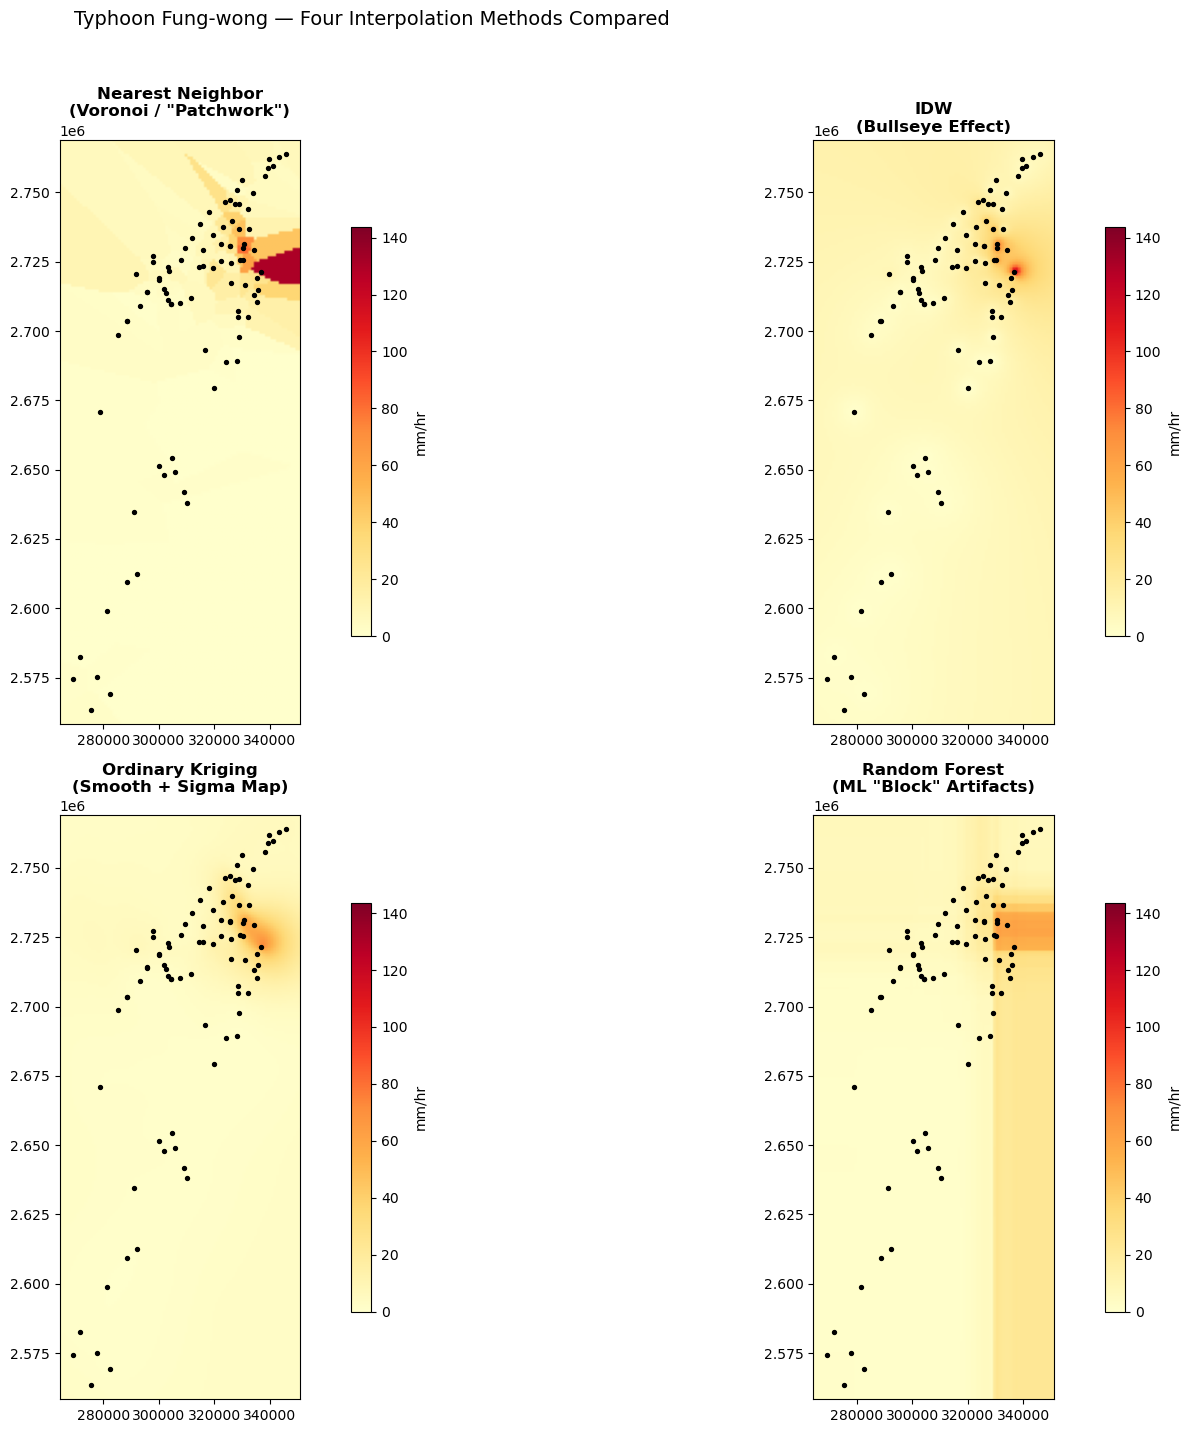

In [11]:
vmax = max(z) * 1.1
methods = [
    ('Nearest Neighbor\n(Voronoi / "Patchwork")', z_nn),
    ('IDW\n(Bullseye Effect)', z_idw),
    ('Ordinary Kriging\n(Smooth + Sigma Map)', z_kriging),
    ('Random Forest\n(ML "Block" Artifacts)', z_rf),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, (title, data) in zip(axes.flatten(), methods):
    im = ax.imshow(data, extent=[x_min, x_max, y_min, y_max],
                   origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax)
    ax.scatter(x, y, c='black', s=8, zorder=5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.7, label='mm/hr')

plt.suptitle('Typhoon Fung-wong — Four Interpolation Methods Compared', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('interpolation_shootout.png', dpi=150, bbox_inches='tight')
plt.show()

### Cell [8]: Kriging vs RF — Direct Comparison

Create a 3-panel comparison: Kriging | Random Forest | Difference Map

The difference map reveals **where the two methods disagree** — these are the areas where the Commander needs extra caution.

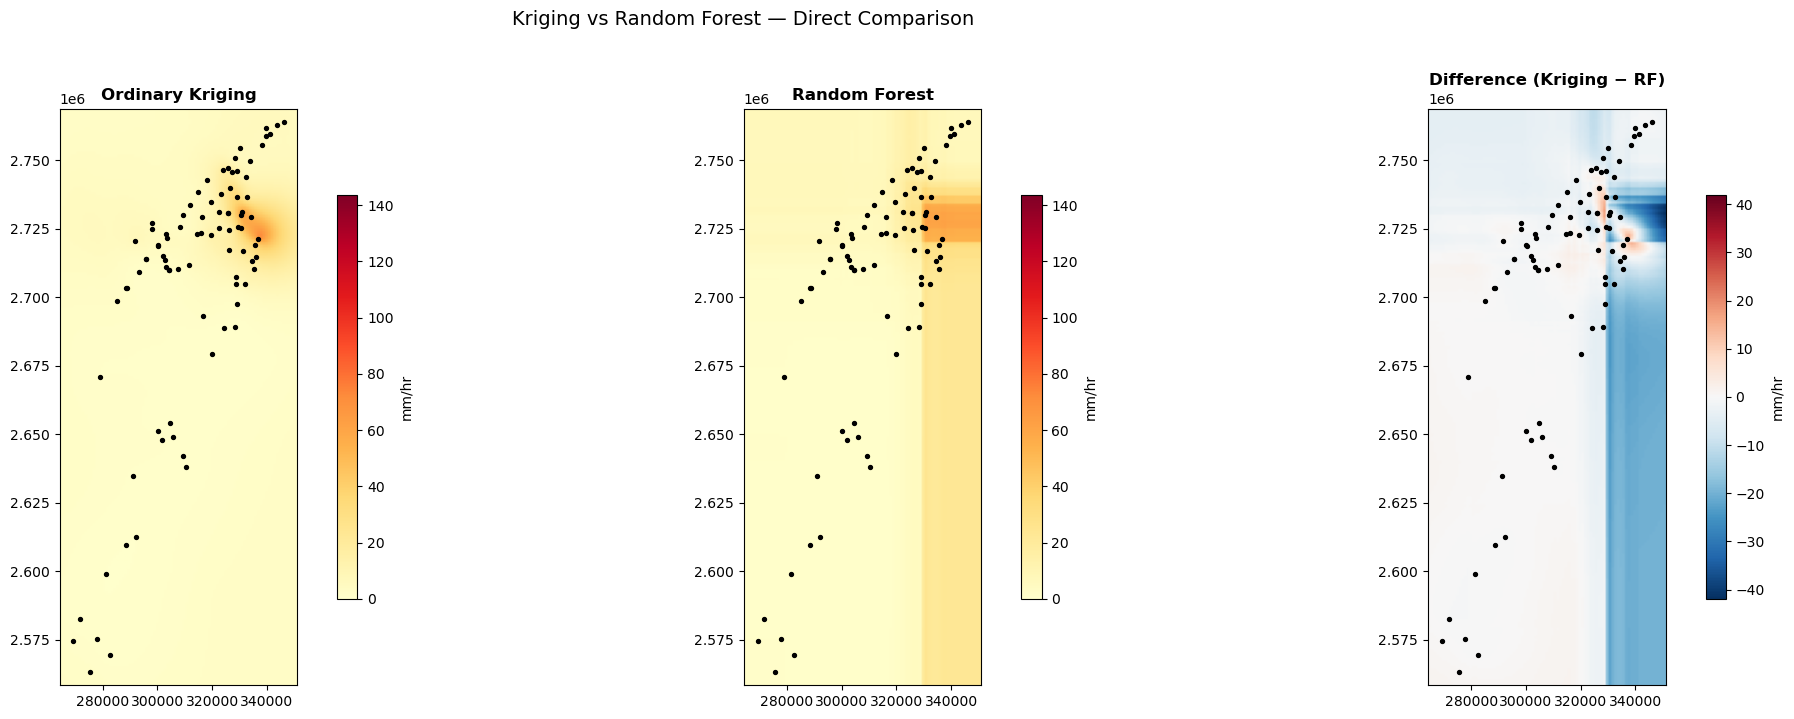

In [12]:
diff = z_kriging - z_rf

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Left: Kriging
im1 = axes[0].imshow(z_kriging, extent=[x_min, x_max, y_min, y_max],
                      origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax)
axes[0].scatter(x, y, c='black', s=8, zorder=5)
axes[0].set_title('Ordinary Kriging', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.7, label='mm/hr')

# Middle: RF
im2 = axes[1].imshow(z_rf, extent=[x_min, x_max, y_min, y_max],
                      origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax)
axes[1].scatter(x, y, c='black', s=8, zorder=5)
axes[1].set_title('Random Forest', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=axes[1], shrink=0.7, label='mm/hr')

# Right: Difference
max_diff = max(abs(np.nanmin(diff)), abs(np.nanmax(diff)))
im3 = axes[2].imshow(diff, extent=[x_min, x_max, y_min, y_max],
                      origin='lower', cmap='RdBu_r', vmin=-max_diff, vmax=max_diff)
axes[2].scatter(x, y, c='black', s=8, zorder=5)
axes[2].set_title('Difference (Kriging − RF)', fontsize=12, fontweight='bold')
plt.colorbar(im3, ax=axes[2], shrink=0.7, label='mm/hr')

plt.suptitle('Kriging vs Random Forest — Direct Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('kriging_vs_rf.png', dpi=150, bbox_inches='tight')
plt.show()

### Lab 1 Reflection

**Questions to answer** (write in the cell below):

1. Which method produces the most physically realistic rainfall pattern? Why?
2. Where do Kriging and RF disagree the most? What does this tell you?
3. What "artifacts" do you observe in the NN and RF results?
4. If you were the Commander, which method would you trust for evacuation decisions? Why?

**Lab 1 反思：**

1. 我覺得最合理的是 **Kriging**。它做出來的雨量面比較連續，測站之間的變化也比較自然。這次雖然只用了測站位置，沒有直接放進地形變數，但和 NN、RF 比起來，Kriging 至少沒有那麼明顯的拼塊感。

2. Kriging 和 RF 差異最大的地方在 **蘇澳附近的高值區，還有東側往外延伸的區域**。Kriging 會從高值中心慢慢往外遞減，RF 則比較像被切成幾塊矩形區域。這讓我覺得 RF 對座標切分很敏感，在需要外推的地方特別容易出現不自然的結果。

3. 我看到的偽影很明顯：**最近鄰（NN）** 有典型的 Voronoi 拼布感，邊界很硬；**隨機森林（RF）** 則有階梯狀和方塊狀區域，看起來像被決策樹切成幾塊。這兩種結果都提醒我，模型算得出來不代表空間分布就一定合理。

4. 如果要拿來做判讀，我會優先看 **Kriging + Sigma Map**。原因不是它一定最準，而是它除了估計值之外，還有不確定性可以一起看。對這種空間預測題目來說，知道哪裡『比較沒把握』其實很重要。

---

## ⏸️ Lab 2: Confidence & Uncertainty Diagnosis (30 min)

### Cell [9]: The Sigma Map — Kriging's Unique Weapon (Slide 15)

**Captain's Log**: This is what makes Kriging special. No other method natively provides a confidence map.

- `ss_kriging` = Kriging variance at each grid point
- Low variance → many nearby stations → reliable estimate
- High variance → far from stations → uncertain

**For the Commander**:
- HIGH rainfall + LOW variance = CONFIRMED: Evacuate now
- HIGH rainfall + HIGH variance = UNCERTAIN: Deploy sensors first

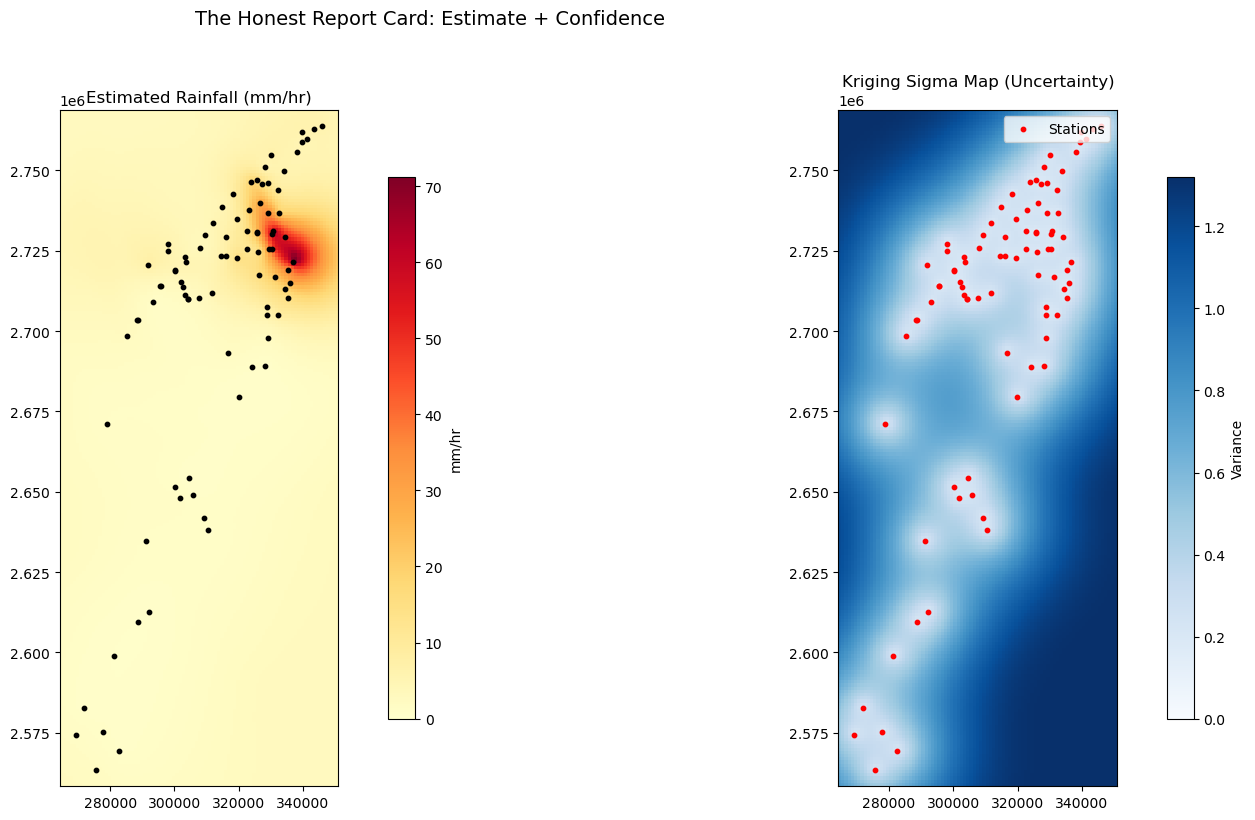

Variance range: 0.172 - 1.320


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Rainfall estimate
im1 = axes[0].imshow(z_kriging, extent=[x_min, x_max, y_min, y_max],
                      origin='lower', cmap='YlOrRd', vmin=0)
axes[0].scatter(x, y, c='black', s=10, zorder=5)
axes[0].set_title('Estimated Rainfall (mm/hr)')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# Kriging Variance (Sigma Map)
im2 = axes[1].imshow(ss_kriging, extent=[x_min, x_max, y_min, y_max],
                      origin='lower', cmap='Blues', vmin=0)
axes[1].scatter(x, y, c='red', s=10, zorder=5, label='Stations')
axes[1].set_title('Kriging Sigma Map (Uncertainty)')
axes[1].legend(loc='upper right')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Variance')

plt.suptitle('The Honest Report Card: Estimate + Confidence', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('sigma_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance range: {np.nanmin(ss_kriging):.3f} - {np.nanmax(ss_kriging):.3f}")

### Cell [9b]: Nugget Effect — Why Extreme Rain Gets Diluted (Slide 7)

Suao recorded **130.5 mm/hr**, but default Kriging predicts only ~71 mm at 500m away. Why?

**Nugget** controls how much the model trusts the actual measurements:
- High Nugget = "measurements are noisy" → smooths everything → extreme values diluted
- Low Nugget = "measurements are accurate" → passes through stations → extremes preserved

**Task**: Compare Nugget=10% vs Nugget=1% on a zoomed-in map around Suao. Which preserves the extreme rainfall better?

**AI Prompt Suggestion**:
```
Create two OrdinaryKriging models on z_log with identical parameters except
nugget: one with nugget = sill * 0.10, one with nugget = sill * 0.01.
Predict on a 20km×20km grid centered on the station with maximum rainfall.
Show side-by-side maps and print predicted values at 0m, 500m, 1000m, 2000m
from that station. Which Nugget preserves the extreme value better?
```

Station with max rainfall: Suao = 130.5 mm/hr

Nugget = 10% sill:
  Offset     0m → 130.5 mm/hr
  Offset   500m → 70.9 mm/hr
  Offset  1000m → 67.3 mm/hr
  Offset  2000m → 61.0 mm/hr

Nugget = 1% sill:
  Offset     0m → 130.5 mm/hr
  Offset   500m → 107.3 mm/hr
  Offset  1000m → 98.8 mm/hr
  Offset  2000m → 85.7 mm/hr


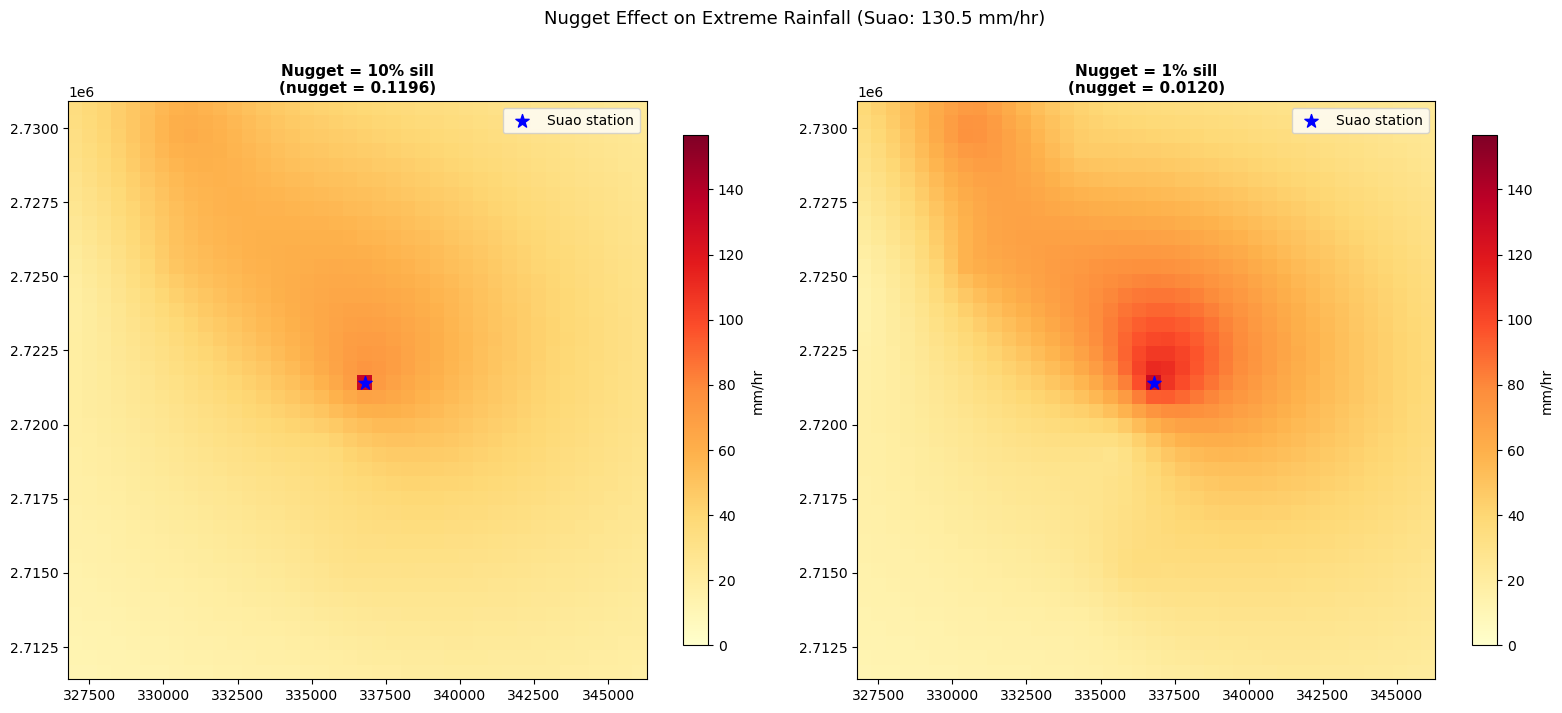


🔑 Nugget = 1% sill preserves the extreme rainfall better.
   For CWA calibrated stations, a lower nugget makes more sense because the observations are relatively trustworthy.


In [14]:
suao_idx = np.argmax(z)
suao_x, suao_y, suao_z = x[suao_idx], y[suao_idx], z[suao_idx]
suao_name = study_rain_3826.iloc[suao_idx]['station_name']
suao_label = 'Suao'
print(f"Station with max rainfall: {suao_label} = {suao_z:.1f} mm/hr")

sill_val  = float(z_log.var())
range_val = 50000.0

configs = {
    'Nugget = 10% sill': sill_val * 0.10,
    'Nugget = 1% sill':  sill_val * 0.01,
}

local_buf = 10000
local_gx = np.arange(suao_x - local_buf, suao_x + local_buf, 500)
local_gy = np.arange(suao_y - local_buf, suao_y + local_buf, 500)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
offsets = [0, 500, 1000, 2000]

for ax, (label, nug) in zip(axes, configs.items()):
    ok_nug = OrdinaryKriging(x, y, z_log, variogram_model='spherical',
                              verbose=False, enable_plotting=False, nlags=15,
                              variogram_parameters={'sill': sill_val,
                                                    'range': range_val,
                                                    'nugget': nug})
    z_local_log, _ = ok_nug.execute('grid', local_gx, local_gy)
    z_local = np.expm1(z_local_log)
    z_local[z_local < 0] = 0

    im = ax.imshow(z_local,
                   extent=[local_gx.min(), local_gx.max(), local_gy.min(), local_gy.max()],
                   origin='lower', cmap='YlOrRd', vmin=0, vmax=suao_z * 1.2)
    ax.scatter([suao_x], [suao_y], c='blue', s=100, marker='*', zorder=5, label='Suao station')
    ax.set_title(f'{label}\n(nugget = {nug:.4f})', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8, label='mm/hr')
    ax.legend()

    print(f"\n{label}:")
    for d in offsets:
        z_pt_log, _ = ok_nug.execute('points', np.array([suao_x + d]), np.array([suao_y]))
        z_pt = np.expm1(z_pt_log[0])
        print(f"  Offset {d:5d}m → {z_pt:.1f} mm/hr")

plt.suptitle(f'Nugget Effect on Extreme Rainfall ({suao_label}: {suao_z:.1f} mm/hr)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n🔑 Nugget = 1% sill preserves the extreme rainfall better.")
print("   For CWA calibrated stations, a lower nugget makes more sense because the observations are relatively trustworthy.")

### Cell [10]: Export to GeoTIFF (Slide 16)

⚠️ **Flip warning**: `z_kriging` row 0 = south (numpy convention). GeoTIFF row 0 = north. Use `np.flipud()` to fix.

**AI Prompt Suggestion**:
```
Save 2D numpy arrays as GeoTIFF using rasterio. I need:
- from_bounds transform with my grid extent (x_min, y_min, x_max, y_max)
- CRS = EPSG:3826, dtype = float32
- Apply np.flipud() before writing
- Save kriging_rainfall.tif, kriging_variance.tif, and rf_rainfall.tif
```

In [15]:
import rasterio
from rasterio.transform import from_bounds

transform = from_bounds(x_min, y_min, x_max, y_max,
                        width=z_kriging.shape[1], height=z_kriging.shape[0])

def save_geotiff(data, filename, crs='EPSG:3826'):
    data_flipped = np.flipud(data).astype(np.float32)
    with rasterio.open(filename, 'w', driver='GTiff',
        height=data_flipped.shape[0], width=data_flipped.shape[1],
        count=1, dtype='float32', crs=crs, transform=transform, nodata=-9999
    ) as dst:
        dst.write(data_flipped, 1)
    print(f"✓ Saved {filename}")

save_geotiff(z_kriging, 'kriging_rainfall.tif')
save_geotiff(ss_kriging, 'kriging_variance.tif')
save_geotiff(z_rf, 'rf_rainfall.tif')

✓ Saved kriging_rainfall.tif
✓ Saved kriging_variance.tif
✓ Saved rf_rainfall.tif


### Cell [11]: Zonal Statistics — Township Decision Table

Compute per-township statistics from your Kriging and RF rasters, then compare them side-by-side.

**Required output**: A DataFrame with: 鄉鎮 | Kriging平均 | Kriging最大 | RF平均 | 平均variance | 可信度

In [16]:
from rasterstats import zonal_stats

try:
    town_shp = DATA_DIR / '鄉(鎮、市、區)界線1140318' / 'TOWN_MOI_1140318.shp'
    towns = gpd.read_file(town_shp)
    study_towns = towns[towns['COUNTYNAME'].isin(['花蓮縣', '宜蘭縣'])].copy()
    study_towns = study_towns.to_crs(epsg=3826)

    kriging_stats = zonal_stats(study_towns, 'kriging_rainfall.tif', stats=['mean', 'max'])
    rf_stats      = zonal_stats(study_towns, 'rf_rainfall.tif',      stats=['mean'])
    var_stats     = zonal_stats(study_towns, 'kriging_variance.tif',  stats=['mean'])

    summary = pd.DataFrame({
        '鄉鎮':         study_towns['TOWNNAME'].values,
        '縣市':         study_towns['COUNTYNAME'].values,
        'Kriging平均':  [s['mean'] if s['mean'] else 0 for s in kriging_stats],
        'Kriging最大':  [s['max']  if s['max']  else 0 for s in kriging_stats],
        'RF平均':       [s['mean'] if s['mean'] else 0 for s in rf_stats],
        '平均variance': [s['mean'] if s['mean'] else 0 for s in var_stats],
    })

    q33 = summary['平均variance'].quantile(0.33)
    q66 = summary['平均variance'].quantile(0.66)
    summary['可信度'] = summary['平均variance'].apply(
        lambda v: 'HIGH' if v < q33 else ('MEDIUM' if v < q66 else 'LOW')
    )

    for c in ['Kriging平均', 'Kriging最大', 'RF平均']:
        summary[c] = summary[c].round(1)
    summary['平均variance'] = summary['平均variance'].round(3)
    summary = summary.sort_values('Kriging平均', ascending=False)
    print(summary.to_string(index=False))

except Exception as e:
    print(f"Township shapefile issue: {e}")

 鄉鎮  縣市  Kriging平均  Kriging最大  RF平均  平均variance    可信度
五結鄉 宜蘭縣       46.2       60.2  51.7       0.226   HIGH
羅東鎮 宜蘭縣       38.7       57.9  31.3       0.206   HIGH
蘇澳鎮 宜蘭縣       37.1       71.2  39.2       0.236   HIGH
冬山鄉 宜蘭縣       28.3       59.7  32.8       0.217   HIGH
宜蘭市 宜蘭縣       28.2       35.3  23.9       0.227   HIGH
壯圍鄉 宜蘭縣       23.6       38.9  31.8       0.232   HIGH
礁溪鄉 宜蘭縣       13.4       23.6  15.0       0.244   HIGH
三星鄉 宜蘭縣        9.4       31.8  11.0       0.237   HIGH
員山鄉 宜蘭縣        8.7       24.5  10.7       0.258 MEDIUM
南澳鄉 宜蘭縣        5.8       32.4   7.3       0.376 MEDIUM
頭城鎮 宜蘭縣        5.8        8.7   9.1       0.250 MEDIUM
大同鄉 宜蘭縣        4.3       17.0   4.6       0.275 MEDIUM
富里鄉 花蓮縣        1.3        2.1   1.0       0.364 MEDIUM
萬榮鄉 花蓮縣        1.1        1.8   0.9       0.636    LOW
秀林鄉 花蓮縣        1.1        2.0   1.1       0.572    LOW
壽豐鄉 花蓮縣        1.0        1.2   0.9       0.400 MEDIUM
卓溪鄉 花蓮縣        1.0        2.1   1.0       0.497    LOW
鳳林鎮 花蓮縣   

### Cell [12]: Thinking Challenge — Why Can't ML Give You a Sigma Map?

**Discussion Questions** (answer in the cell below):

1. Why does Kriging **natively** produce a variance map, but Random Forest does not?
2. Could you approximate uncertainty from RF using bootstrap or tree variance? What are the limitations?
3. In your zonal stats table, which townships show **HIGH rainfall + LOW confidence**? What should the Commander do about those?

**Lab 2 反思：**

1. Kriging 會自然產生 variance map，因為它本來就是建立在空間統計模型上，會一起估計預測值和預測誤差。Random Forest 比較像是很多棵樹一起投票的結果，主要給我一個預測值，本身沒有直接附帶空間上的不確定性。

2. RF 不是完全不能談不確定性，可以用 bootstrap 重複訓練，或看不同樹之間的預測差異。不過這些做法比較像是在看模型本身穩不穩定，不像 Kriging 那樣直接把空間相關性放進去，所以兩者的意義還是不太一樣。

3. 這次表格裡，其實**沒有很明顯的「高降雨 + 低可信度」鄉鎮**。高降雨主要集中在宜蘭，而且多半靠近測站，所以可信度反而偏高。低可信度的地方比較常出現在花蓮山區或站點較少的區域，但那些地方這次的預測雨量並不高。這代表指揮上應該把它們當成「需要持續監測的區域」，而不是直接當成已確認的高風險熱區。

### Cell [13]: (Bonus) AI Advisor Consultation

Ask an AI model (Gemini, ChatGPT, or Claude):

> 「在花蓮山區，測站密度約 1 站 / 50 km²。我用 Kriging 和 Random Forest 分別做了降雨內插，結果在山區差異很大。Kriging 的 variance 在山區也很高。請問：(1) 我應該信哪個結果？(2) 如何改善山區的預測品質？」

Paste the AI's response below and write your own commentary.

**AI 回覆：**

在花蓮山區，測站密度約 1 站 / 50 km² 的情況下：

(1) **兩種方法都不應盲目信任**，但 Kriging 較為合適，因為它透過變異數地圖誠實地報告不確定性。在 Kriging 變異數高的地方，你知道預測不可靠；RF 則只給出一個數字，沒有信心區間。

(2) 改善山區預測的方法：
- 加入**高程（DEM）**作為協變量 → 協同克利金（Co-Kriging）或外部漂移克利金（KED）
- 使用**雷達QPE**（定量降水估計）作為補充的網格資料
- 納入**地形性降水模型**以考慮迎風面/背風面的不對稱效應
- 在資料稀疏的山區河谷**部署 IoT 雨量計**

**我的評論：**

我覺得 AI 提的方向蠻合理的。以這次結果來看，只用 x、y 座標去做 RF 還是不太夠，因為東部山區的降雨明顯和地形有關。如果後續要改進，我會優先考慮把 DEM 或雷達 QPE 加進來。另外我這次最大的收穫是，不確定性地圖真的很重要，至少可以分清楚哪些地方是比較有把握的結果，哪些地方只是模型推估。

---

## ARIA Evolution Recap

| Version | Week | Capability | Key Question |
|---------|------|-----------|---------------|
| v1.0 | W3 | River buffer + shelters | How close to the river? |
| v2.0 | W4 | + DEM terrain analysis | How steep is the terrain? |
| v3.0 | W5 | + Real-time rainfall stations | How much rain RIGHT NOW? |
| **v3.5** | **W6** | **+ Kriging & ML interpolation** | **What about areas with NO station? How confident are we?** |
| v4.0 | Final Project | Your extension! | Your question! |

---

*"Interpolation is not just filling space; it is predicting risk where sensors cannot reach."*